In [7]:
import warnings
warnings.filterwarnings('ignore')
import sys
print(sys.executable)

C:\Users\aksha\AppData\Local\Programs\Python\Python312\python.exe


# Decomposing Time Series into Trend, Seasonality & Residual

## AIRLINE PASSENGERS

##### Addictive:  Yt​=Trendt​+Seasonalityt​+Residualt​

##### Multiplicative: Yt​=Trendt​×Seasonalityt​×Residualt​

In [2]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

In [5]:
data = data = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

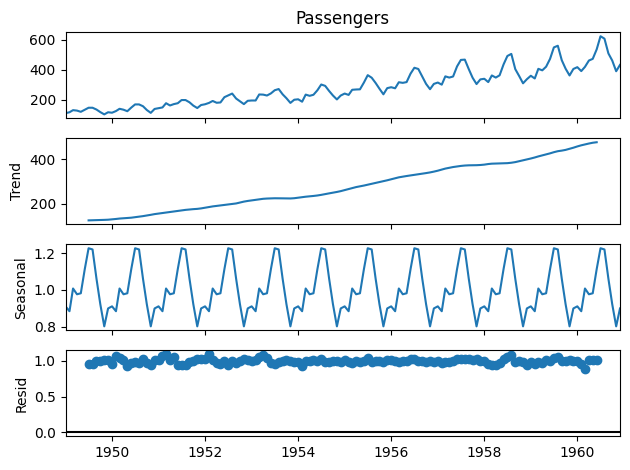

In [8]:
result = seasonal_decompose(data['Passengers'], model='multiplicative')
result.plot()
plt.show()

<Axes: xlabel='Month'>

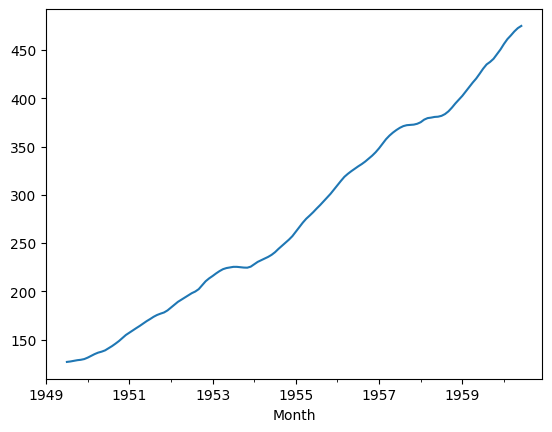

In [11]:
result.trend.plot()

<Axes: xlabel='Month'>

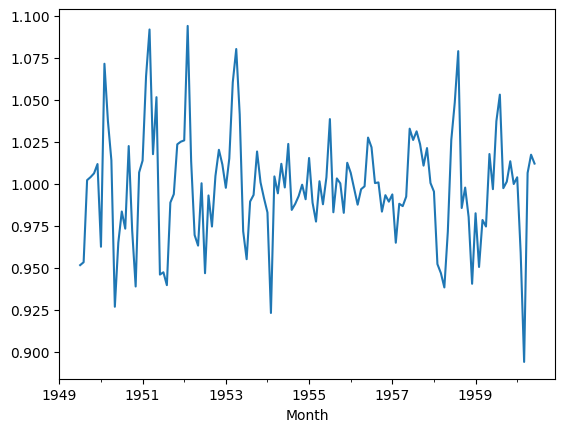

In [12]:
result.resid.plot()

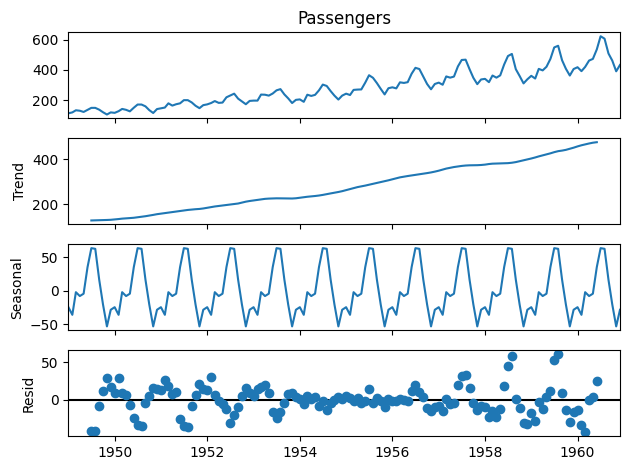

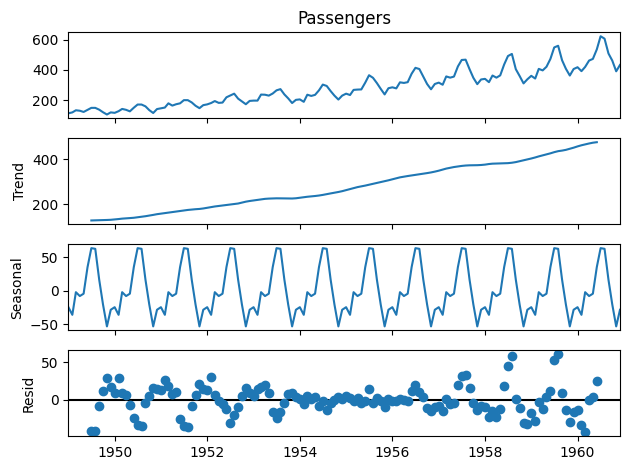

In [13]:
result = seasonal_decompose(data['Passengers'], model='addictive')
result.plot()

#### whixh model?

Trend only → ARIMA or Holt

Trend + Seasonality → SARIMA or Holt-Winters

Seasonality only → Holt-Winters (no trend)

None → ARIMA / Simple Smoothing

Irregular or non-linear → Prophet or ML

## AAPL Stock prices

In [8]:
import yfinance as yf
import matplotlib.pyplot as plt

In [16]:
stock_data = yf.download('AAPL', start='2024-01-01', end='2024-08-01')
stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,184.081512,186.858009,182.346204,185.578830,82488700
2024-01-03,182.703171,184.319491,181.890048,182.673424,58414500
2024-01-04,180.382812,181.552899,179.361461,180.620788,71983600
2024-01-05,179.658936,181.225673,178.657420,180.462148,62379700
2024-01-08,184.002182,184.041855,179.976269,180.561312,59144500


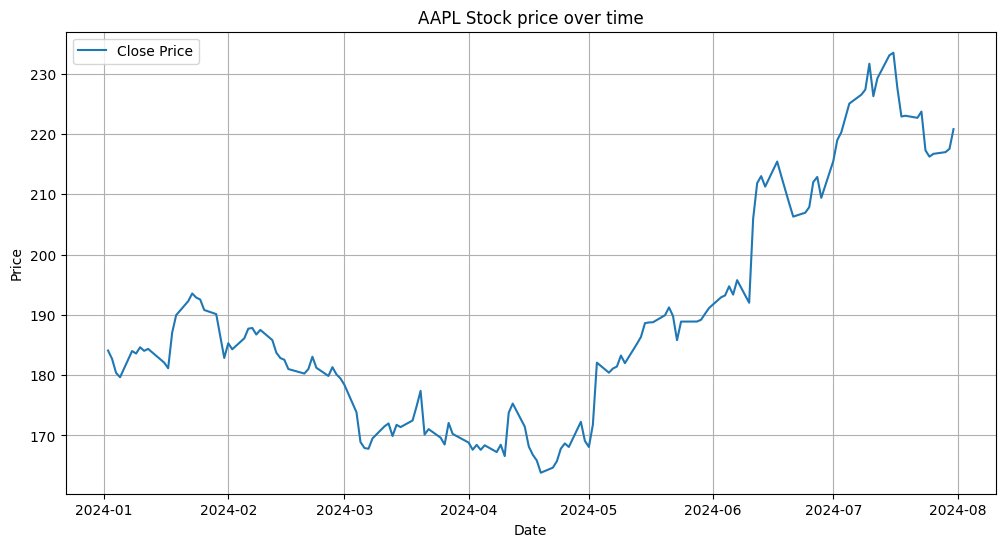

In [17]:
plt.figure(figsize=(12,6))
plt.plot(stock_data.index, stock_data['Close'], label='Close Price')
plt.title('AAPL Stock price over time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

add_dcmp = seasonal_decompose(stock_data['Close'], model='additive', period=30)

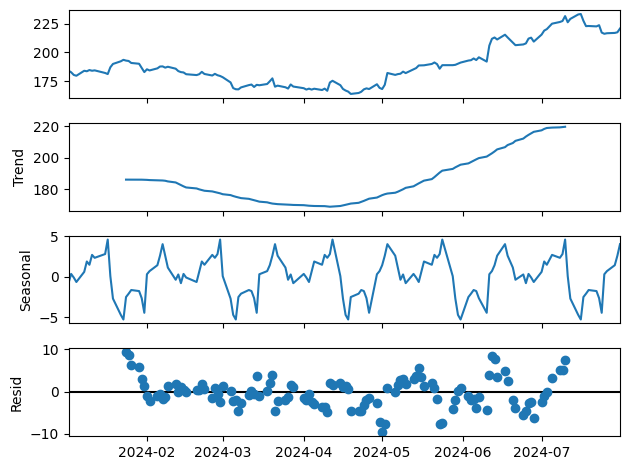

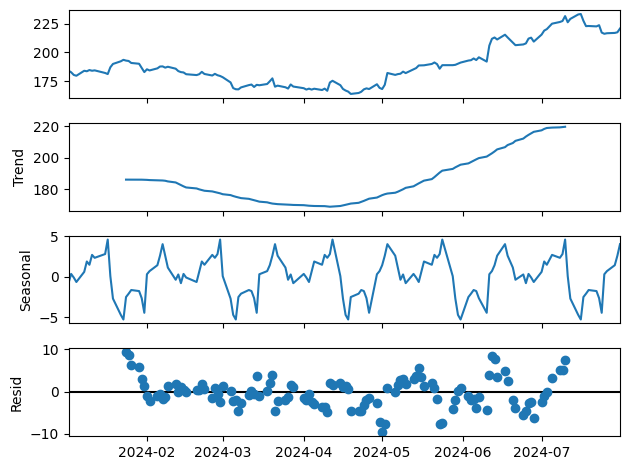

In [19]:
add_dcmp.plot()

# STL Decomposition using LOESS
#### locally estimated scatterplot smoothing

- handle outlieres in timeseries data
- better for finding actual seasonal patterns
- only handle additive model

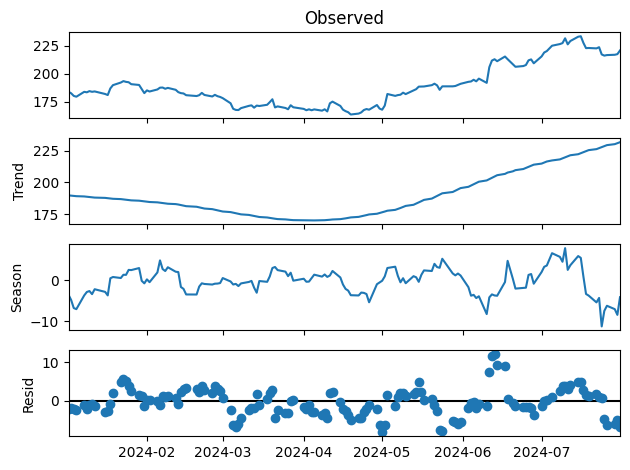

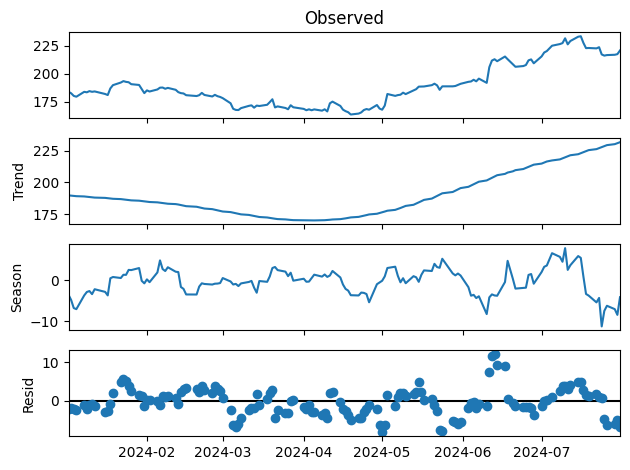

In [26]:
from statsmodels.tsa.seasonal import STL
stl = STL(stock_data['Close'], period=30)
result = stl.fit()
result.plot()

### white noise and random walk

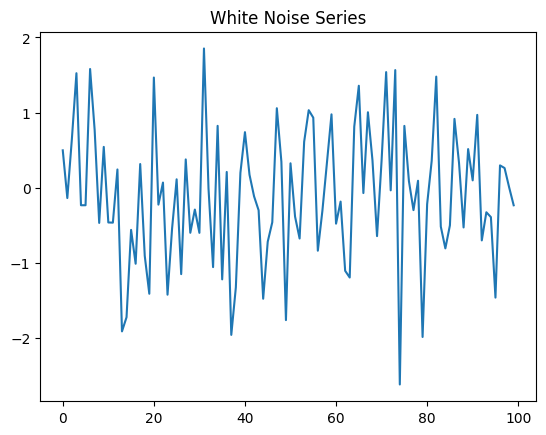

In [27]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
white_noise = np.random.normal(0, 1, 100)

plt.plot(white_noise)
plt.title("White Noise Series")
plt.show()


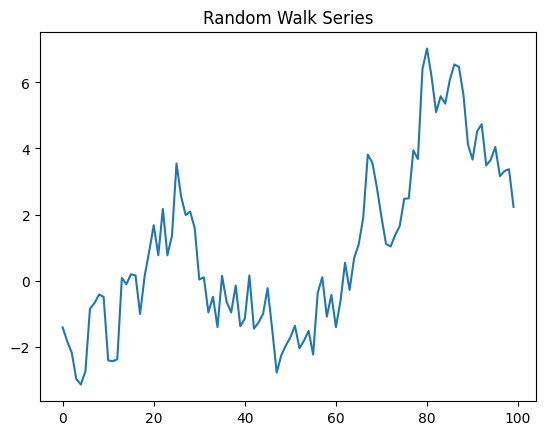

In [28]:
random_steps = np.random.normal(0, 1, 100)
random_walk = np.cumsum(random_steps)  # cumulative sum

plt.plot(random_walk)
plt.title("Random Walk Series")
plt.show()
